Food Price Prediction
## Data Cleaning & Exploratory Data Analysis (CRISP-DM: Data Preparation)

## Dataset 
Food_price_prediction.csv  monthly food commodity prices in Kenya (2006–2026) merged with macroeconomic indicators (inflation, central bank rate) and weather variables (rainfall, temperature, humidity, wind speed), engineered lag/rolling features, and a forecasting target 

This notebook performs, in order:
1. Initial inspection
2. Step-by-step cleaning 
3. Full exploratory data analysis (EDA) and focusing objective


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', 50)
pd.set_option('display.width', 160)
sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 100

df = pd.read_csv('food_price_prediction.csv')
print("Shape:", df.shape)
df.head()

Shape: (1878, 22)


,date,commodity,food_price,inflation_annual_avg,inflation_12m,central_bank_rate,rainfall,temperature,temperature_max,temperature_min,humidity,wind_speed,food_price_lag_1,food_price_lag_3,food_price_lag_6,food_price_lag_12,food_price_change_1m,food_price_ma_3,food_price_ma_6,central_bank_rate_change_1m,target_food_price_next_month,target_date
0,2006-01-01,Beans (dry),39.0,9.36,8.39,9.296392,1.145823,24.324359,30.912066,18.847842,62.257247,3.792183,NaN,NaN,NaN,NaN,NaN,39.00,39.00,NaN,42.0,2006-02-01
1,2006-01-01,Maize (white),23.5,9.36,8.39,9.296392,1.145823,24.324359,30.912066,18.847842,62.257247,3.792183,NaN,NaN,NaN,NaN,NaN,23.50,23.50,NaN,25.0,2006-02-01
2,2006-01-01,Oil (vegetable),115.0,9.36,8.39,9.296392,1.145823,24.324359,30.912066,18.847842,62.257247,3.792183,NaN,NaN,NaN,NaN,NaN,115.00,115.00,NaN,120.0,2006-02-01
3,2006-02-01,Beans (dry),42.0,9.01,9.39,9.258021,0.854813,25.384639,32.413195,19.443096,58.030785,3.961852,39.0,NaN,NaN,NaN,3.0,40.50,40.50,-0.03837,47.0,2006-03-01
4,2006-02-01,Maize (white),25.0,9.01,9.39,9.258021,0.854813,25.384639,32.413195,19.443096,58.030785,3.961852,23.5,NaN,NaN,NaN,1.5,24.25,24.25,-0.03837,24.5,2006-03-01



## Data Cleaning



## Step 1: Inspect structure and data types


In [3]:
print(df.dtypes)
print()
print("Rows:", len(df), "| Columns:", df.shape[1])
print("Date range (raw):", df['date'].min(), "to", df['date'].max())

date                             object
commodity                        object
food_price                      float64
inflation_annual_avg            float64
inflation_12m                   float64
central_bank_rate               float64
rainfall                        float64
temperature                     float64
temperature_max                 float64
temperature_min                 float64
humidity                        float64
wind_speed                      float64
food_price_lag_1                float64
food_price_lag_3                float64
food_price_lag_6                float64
food_price_lag_12               float64
food_price_change_1m            float64
food_price_ma_3                 float64
food_price_ma_6                 float64
central_bank_rate_change_1m     float64
target_food_price_next_month    float64
target_date                      object
dtype: object

Rows: 1878 | Columns: 22
Date range (raw): 2006-01-01 to 2026-07-01


## Finding
Date and target_date are stored as strings (object), not datetime. 
Everything else is already numeric except commodity, which is text as expected.

## Action 
Convert date and target_date to proper datetime64  required for correct chronological sorting, time-series plotting, and any date-based feature engineering.

In [5]:
df['date'] = pd.to_datetime(df['date'])
df['target_date'] = pd.to_datetime(df['target_date'])
print(df[['date','target_date']].dtypes)

date           datetime64[ns]
target_date    datetime64[ns]
dtype: object


## Step 2: Check for duplicate records

In [13]:
exact_dupes = df.duplicated().sum()
key_dupes = df.duplicated(subset=['date','commodity']).sum()
print("Fully identical duplicate rows:", exact_dupes)
print("Duplicate (date, commodity) combinations:", key_dupes)

Fully identical duplicate rows: 0
Duplicate (date, commodity) combinations: 0


## Step 3: Standardize the commodity text field


In [9]:
before = df['commodity'].nunique()
df['commodity'] = df['commodity'].astype(str).str.strip()

# check for names that only differ by case
name_groups = {}
for name in df['commodity'].unique():
    name_groups.setdefault(name.lower(), []).append(name)
case_variants = {k: v for k, v in name_groups.items() if len(v) > 1}

print("Unique commodities before/after stripping whitespace:", before, "/", df['commodity'].nunique())
print("Case-only duplicate names found:", case_variants if case_variants else "None")

Unique commodities before/after stripping whitespace: 26 / 26
Case-only duplicate names found: None


#### Finding: no whitespace or case inconsistencies 

## Step 4: Validate value ranges (impossible / invalid values)

Check every numeric column against what's physically or logically possible for that variable, rather than assuming the data is correct:
- Prices should be > 0
- Rainfall/wind speed should be ≥ 0
- Humidity should be within 0–100%
- Temperature_min should never exceed temperature_max
- Central bank rate should be ≥ 0

In [6]:
checks = {
    'food_price <= 0': (df['food_price'] <= 0).sum(),
    'rainfall < 0': (df['rainfall'] < 0).sum(),
    'wind_speed < 0': (df['wind_speed'] < 0).sum(),
    'humidity outside 0-100': ((df['humidity'] < 0) | (df['humidity'] > 100)).sum(),
    'temperature_min > temperature_max': (df['temperature_min'] > df['temperature_max']).sum(),
    'central_bank_rate < 0': (df['central_bank_rate'] < 0).sum(),
}
for k, v in checks.items():
    print(f"{k}: {v} violations")

food_price <= 0: 0 violations
rainfall < 0: 0 violations
wind_speed < 0: 0 violations
humidity outside 0-100: 0 violations
temperature_min > temperature_max: 0 violations
central_bank_rate < 0: 0 violations


**Finding:** zero violations across every check. The dataset has no physically impossible values no negative prices, no out-of-range humidity, no inverted temperature bounds. No rows need to be dropped or corrected on this basis.

## Step 5: Handle missing values

Missing values need to be diagnosed **before** deciding what to do with them  a gap has a different correct treatment depending on *why* it's missing.

In [7]:
missing = df.isna().sum()
missing = missing[missing > 0].sort_values(ascending=False)
print(missing)
print()
print("Total rows:", len(df))

food_price_lag_12              291
food_price_lag_6               138
food_price_lag_3                61
central_bank_rate_change_1m     25
food_price_lag_1                22
food_price_change_1m            22
dtype: int64

Total rows: 1878


**Diagnosis:** 
All missing values are confined to the engineered lag/rolling features (food price lag_1/3/6/12, food price change_1m, central_bank_rate_change_1m). This is **structural, not random** a lag-12 feature is undefined for a commodity's first 12 months in the dataset, because there is no data 12 months earlier to reference. This is confirmed below: missing counts increase with the lag length (22  61 138  291), exactly as expected if the cause is "not enough history yet" rather than a data collection failure.

In [8]:
# Confirm the missing pattern is driven by each commodity's start of history
first_appearance = df.groupby('commodity')['date'].min()
print("Commodities and their first recorded month (sample):")
print(first_appearance.sort_values().head(8))
print()

# Show that lag_12 missingness clusters at the start of each commodity's series
sample_commodity = 'Bananas'
sub = df[df['commodity'] == sample_commodity].sort_values('date')
print(f"\nFirst 5 rows for '{sample_commodity}' — note lag_12 is NaN until 12 months of history exist:")
print(sub[['date','food_price','food_price_lag_1','food_price_lag_12']].head(5))

Commodities and their first recorded month (sample):
commodity
Beans (dry)        2006-01-01
Maize (white)      2006-01-01
Oil (vegetable)    2006-01-01
Bananas            2018-12-01
Sugar              2018-12-01
Salt               2018-12-01
Rice               2018-12-01
Potatoes (Irish)   2018-12-01
Name: date, dtype: datetime64[us]


First 5 rows for 'Bananas' — note lag_12 is NaN until 12 months of history exist:
          date  food_price  food_price_lag_1  food_price_lag_12
461 2018-12-01       10.00               NaN                NaN
542 2021-01-01       10.00              8.00                NaN
567 2021-02-01       18.75             10.00                NaN
592 2021-03-01       10.00             18.75                NaN
617 2021-04-01       10.00             10.00                NaN


**Decision:** These NaNs are *not* imputed with a mean/median, because doing so would fabricate a false price history where none exists that would leak misleading signal into a forecasting model. Instead, two clean options are prepared:

 **Option A (used for tree-based models  Random Forest / XGBoost):** leave the NaNs as is. These models handle missing values natively via their split logic, and this preserves the true "no history yet" signal.
 **Option B (for models that require complete cases  e.g. ARIMA baselines):** drop only the rows lacking the specific lag needed by that model, rather than dropping rows globally  this avoids discarding valid recent data just because a commodity's early history is short.

Both derived datasets are saved at the end of this notebook so either modeling approach can use the correct one.

## Step 6: Check for extreme values / inconsistent price scales

Before flagging anything as an "outlier" to be removed, we check *why* it looks extreme in commodity price data, apparent outliers are often genuine scale differences (e.g. price per bag vs. price per kg) rather than errors.

In [9]:
price_scale = df.groupby('commodity')['food_price'].agg(['min','max','mean']).sort_values('max', ascending=False)
print(price_scale)

                             min        max          mean
commodity                                                
Beans (dolichos)         6875.10  15717.000  10275.383537
Beans (rosecoco)         6660.00  14268.000  10301.600833
Cowpeas                  2100.42  13050.000   8254.915288
Tomatoes                 2645.50  10628.480   4328.089032
Rice (aromatic)          5000.00   9350.000   7308.363111
Maize (white, dry)       2618.00   6494.500   4284.873203
Potatoes (Irish, white)  1150.00   5750.000   2870.572417
Potatoes (Irish, red)    1260.50   4688.335   2597.353667
Onions (dry)              527.00   1950.000   1019.267018
Meat (goat)               477.78    850.000    644.367143
Meat (camel)              400.00    750.000    553.837193
Meat (beef)               440.00    700.000    560.504583
Oil (vegetable)           108.00    306.250    201.009850
Milk (camel, fresh)        62.50    250.000    166.615686
Sugar                     106.50    235.000    153.572155
Beans (dry)   

**Finding:** commodities split into two clear price tiers:
- **Bagged/bulk staples** Beans dolichos, Beans (rosecoco), Cowpeas, Tomatoes, Rice aromatic, Maize white, dry, Potatoes Irish, white/red, Onions (dry)  priced in the thousands of KES, consistent with bag/crate-level market pricing.
- **Retail unit staples** Beans (dry), Maize (white), Oil (vegetable), Sugar, Rice`, priced in tens to low hundreds of KES, consistent with per kg/per litre retail pricing.

**Decision:** this is **not a data error** it reflects real, different units of sale across commodities, which is normal for Kenyan market price surveys (KNBS/FEWS NET-style data). No values are altered. However, it means:
- Cross-commodity price comparisons must be **normalized** e.g. z-score or log scale  done in the EDA section below.
- Any model trained across multiple commodities together should either include commodity as a categorical feature or be trained per commodity group, so the model doesn't confuse a bag price with a per kg price.

## Step 7: Check extreme month-over-month price swings

Separately from scale, check for sudden single-month jumps that could indicate a genuine data entry error rather than real volatility.

In [10]:
df_sorted = df.sort_values(['commodity','date']).copy()
df_sorted['pct_change_1m'] = (df_sorted['food_price_change_1m'] / df_sorted['food_price_lag_1']) * 100

top_swings = df_sorted.reindex(df_sorted['pct_change_1m'].abs().sort_values(ascending=False).index)
print(top_swings[['date','commodity','food_price_lag_1','food_price','pct_change_1m']].head(8).to_string(index=False))

      date        commodity  food_price_lag_1  food_price  pct_change_1m
2025-09-01          Cowpeas           2100.42     7200.00     242.788585
2025-11-01         Tomatoes           3040.00     8114.50     166.924342
2025-04-01         Tomatoes           4160.00    10628.48     155.492308
2024-12-01 Beans (dolichos)           4500.00    10066.50     123.700000
2024-12-01         Tomatoes           2400.00     5158.08     114.920000
2022-02-01          Bananas             10.00       20.00     100.000000
2024-07-01          Bananas             10.00       20.00     100.000000
2024-10-01          Bananas             10.00       20.00     100.000000


**Finding:** the largest swings belong to **Cowpeas** and **Tomatoes** both are well documented in Kenyan markets as highly seasonal, perishable commodities whose retail prices can more than double within a month around planting/harvest gaps or supply shocks. This matches real world behavior rather than a measurement error, so these values are **kept, not removed**  clipping them would remove exactly the volatility a forecasting model needs to learn to anticipate.

**Decision:** no swings are treated as errors and removed. If a modeling step later needs variance stabilization, a log-transform of food rice (applied per commodity) is the appropriate tool not deletion.

## Step 8: Check temporal coverage per commodity

A model needs to know how much history actually exists per commodity before it can be trusted at that commodity's forecast.

In [11]:
total_months = df['date'].nunique()
coverage = df['commodity'].value_counts().sort_values()
print(f"Total distinct months in the dataset: {total_months}")
print()
print("Records per commodity (ascending — least history first):")
print(coverage)

Total distinct months in the dataset: 247

Records per commodity (ascending — least history first):
commodity
Beans (rosecoco)            36
Meat (beef)                 36
Beans (dolichos)            41
Potatoes (Irish, red)       45
Rice (aromatic)             45
Milk (camel, fresh)         51
Sorghum                     52
Cowpeas                     52
Milk (UHT)                  53
Maize                       56
Meat (goat)                 56
Meat (camel)                57
Onions (dry)                57
Maize flour                 58
Potatoes (Irish)            58
Bananas                     58
Sugar                       58
Salt                        58
Wheat flour                 58
Rice                        58
Potatoes (Irish, white)     60
Tomatoes                    62
Maize (white, dry)          64
Maize (white)              179
Oil (vegetable)            233
Beans (dry)                237
Name: count, dtype: int64


**Finding:** coverage is highly uneven. Beans (dry), Oil (vegetable), and Maize (white) span most of the full 2006–2026 window (179–237 months), while commodities like Meat (beef) and Beans (rosecoco) only have 36 months of history. This is a **data understanding fact to carry into modeling**, not something to "fix" by fabricating history it means per commodity forecast reliability will vary, and commodities with short history need either a simpler model, a shorter training window, or should borrow strength from correlated commodities/features rather than being modeled with long lag features they don't have enough data to support.

## Step 9: Validate the engineered target column

Since target food price next month was pre engineered into the file, we verify it actually equals the following month's real recorded price for that commodity this catches any misalignment before it silently corrupts model training.

In [12]:
check = df.merge(
    df[['date','commodity','food_price']],
    left_on=['target_date','commodity'], right_on=['date','commodity'],
    suffixes=('','_actual_next')
)
mismatches = check[(check['target_food_price_next_month'] - check['food_price_actual_next']).abs() > 0.01]
print(f"Rows checked: {len(check)}")
print(f"Mismatches between target column and actual next-month price: {len(mismatches)}")

Rows checked: 1779
Mismatches between target column and actual next-month price: 0


**Finding:** 0 mismatches out of 1,779 checkable rows (the remainder are the most recent month per commodity, where no "next month" exists yet in the data to check against — expected, not an error). The target column is trustworthy.

## Step 10: Sort chronologically and finalize

Sort by commodity then date (required for any lag/rolling feature or time-series split to behave correctly), and save two cleaned outputs per the Step 5 decision.

In [13]:
df_clean = df.sort_values(['commodity','date']).reset_index(drop=True)

# Version A: keep structural NaNs (for tree-based models)
df_clean.to_csv('food_price_cleaned_full.csv', index=False)

# Version B: complete-case dataset (drop rows missing any lag feature) — for models needing no NaNs
lag_cols = ['food_price_lag_1','food_price_lag_3','food_price_lag_6','food_price_lag_12',
            'food_price_change_1m','central_bank_rate_change_1m']
df_complete = df_clean.dropna(subset=lag_cols).reset_index(drop=True)
df_complete.to_csv('food_price_cleaned_complete_case.csv', index=False)

print("Cleaned (structural NaNs kept):", df_clean.shape)
print("Cleaned (complete case, NaNs dropped):", df_complete.shape)
print(f"Rows dropped for complete-case version: {len(df_clean) - len(df_complete)} "
      f"({(len(df_clean)-len(df_complete))/len(df_clean):.1%}) — all are early-history rows per commodity, as diagnosed in Step 5.")

Cleaned (structural NaNs kept): (1878, 22)
Cleaned (complete case, NaNs dropped): (1587, 22)
Rows dropped for complete-case version: 291 (15.5%) — all are early-history rows per commodity, as diagnosed in Step 5.



# Part 2 Exploratory Data Analysis (EDA)

Now that the data is validated and cleaned, we explore it to understand patterns relevant to the forecasting objective: what drives food_price and its next-month target, which commodities are easiest/hardest to forecast, and how the macro/weather features relate to price.


In [14]:
df = pd.read_csv('food_price_cleaned_full.csv', parse_dates=['date','target_date'])
df.head()

,date,commodity,food_price,inflation_annual_avg,inflation_12m,central_bank_rate,rainfall,temperature,temperature_max,temperature_min,humidity,wind_speed,food_price_lag_1,food_price_lag_3,food_price_lag_6,food_price_lag_12,food_price_change_1m,food_price_ma_3,food_price_ma_6,central_bank_rate_change_1m,target_food_price_next_month,target_date
0,2018-12-01,Bananas,10.00,4.69,5.71,9.0,2.113507,24.146886,30.013344,19.406097,68.983633,3.786694,NaN,NaN,NaN,NaN,NaN,10.000000,10.000,NaN,10.000,2019-01-01
1,2021-01-01,Bananas,10.00,5.74,5.69,7.0,0.791935,23.907548,30.624000,18.401032,63.947161,3.856129,8.00,10.0,NaN,NaN,2.00,9.333333,9.500,-2.0,18.750,2021-02-01
2,2021-02-01,Bananas,18.75,5.16,5.78,7.0,1.044286,24.799500,31.690571,19.063571,59.523000,3.674143,10.00,10.0,NaN,NaN,8.75,12.250000,11.350,0.0,10.000,2021-03-01
3,2021-03-01,Bananas,10.00,5.17,5.90,7.0,1.791161,25.173806,31.998323,19.619355,59.837871,4.444710,18.75,8.0,NaN,NaN,-8.75,12.916667,11.125,0.0,10.000,2021-04-01
4,2021-04-01,Bananas,10.00,4.66,5.76,7.0,2.957933,24.550467,30.218667,20.136867,69.454067,4.395667,10.00,10.0,10.0,NaN,0.00,12.916667,11.125,0.0,12.395,2021-05-01


## 2.1 Overall shape and summary statistics

A first numeric summary across all commodities pooled together useful as a baseline, though (per Step 6) it mixes different price scales, so it's read as a sanity check rather than a per-commodity insight.

In [15]:
df.describe().T[['count','mean','std','min','25%','50%','75%','max']]

,count,mean,std,min,25%,50%,75%,max
date,1878,2020-10-15 01:43:30.862619,NaN,2006-01-01 00:00:00,2018-12-01 00:00:00,2022-10-01 00:00:00,2024-08-01 00:00:00,2026-07-01 00:00:00
food_price,1878.0,1414.154036,2807.368671,9.89,66.51625,135.0,700.0,15717.0
inflation_annual_avg,1878.0,6.33386,2.408273,3.55,4.66,5.77,7.395,17.07
inflation_12m,1878.0,6.279414,2.765275,1.85,4.47,5.8,6.86,19.72
central_bank_rate,1878.0,9.547306,2.161785,5.75,8.25,9.5,10.5,18.0
rainfall,1878.0,2.298719,1.79927,0.12,1.055613,1.658513,2.883667,9.333467
temperature,1878.0,23.951953,1.072486,21.694516,23.023067,24.137874,24.6326,26.167613
temperature_max,1878.0,30.108134,1.471869,27.348452,28.840667,30.013344,31.214093,33.591613
temperature_min,1878.0,19.003799,0.917936,16.916645,18.206667,19.169279,19.6746,20.995677
humidity,1878.0,66.067181,5.569413,51.113643,62.014515,66.317172,69.224323,78.724933


**Reading:** the huge gap between the `75%` (700) and `max` (~15,717) confirms what Step 6 found — pooled statistics are dominated by the high-value bagged commodities. This is why all analysis below is done **per commodity**, not on the pooled column.

## 2.2 Data coverage over time and across commodities

Visualizing how much data exists per commodity makes the imbalance from Step 8 concrete, and shows which commodities can support long-history forecasting models.

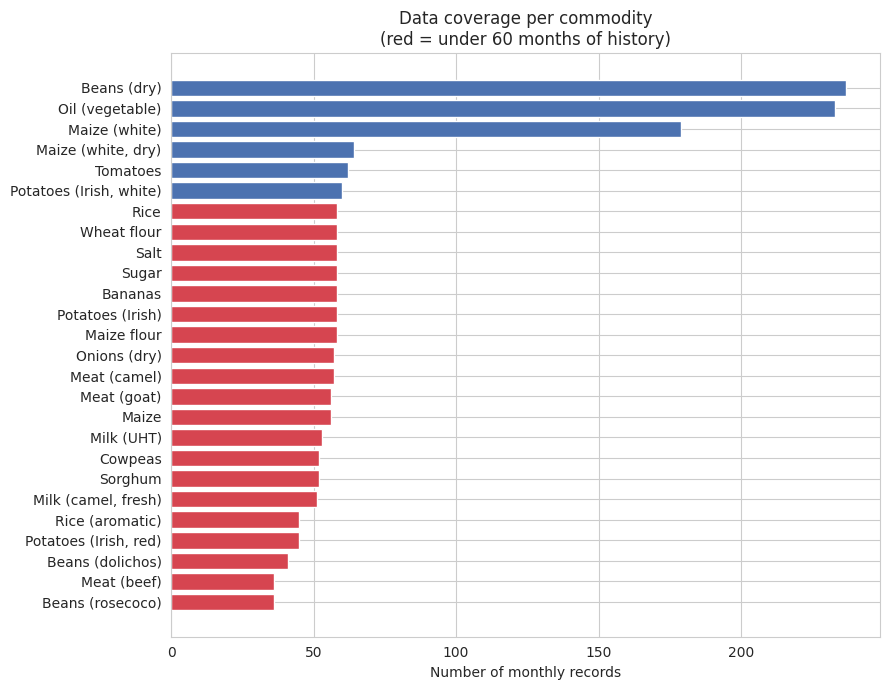

In [16]:
fig, ax = plt.subplots(figsize=(9,7))
counts = df['commodity'].value_counts().sort_values()
colors = ['#d64550' if c < 60 else '#4c72b0' for c in counts.values]
ax.barh(counts.index, counts.values, color=colors)
ax.set_xlabel('Number of monthly records')
ax.set_title('Data coverage per commodity\n(red = under 60 months of history)')
plt.tight_layout()
plt.show()

**Insight:** three commodities (Beans (dry), Oil (vegetable), Maize (white)) anchor the dataset with long, near complete histories going back to 2006  these are the strongest candidates for a robust time series forecasting model with long lags (lag 12, rolling 6). Commodities in red have under 5 years of history, which limits them to shorter lag features and simpler models.

## 2.3 Price trends over time for the core long history commodities

Plotting the actual price trajectories for the commodities with the longest history shows the trend and volatility a forecasting model needs to capture.

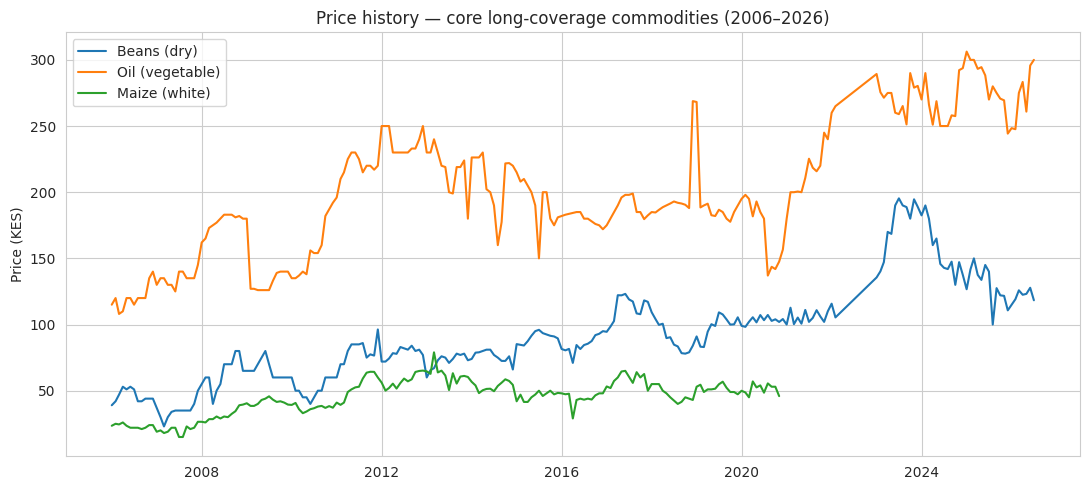

In [17]:
core_commodities = ['Beans (dry)', 'Oil (vegetable)', 'Maize (white)']
fig, ax = plt.subplots(figsize=(11,5))
for c in core_commodities:
    sub = df[df['commodity']==c].sort_values('date')
    ax.plot(sub['date'], sub['food_price'], label=c)
ax.set_ylabel('Price (KES)')
ax.set_title('Price history — core long-coverage commodities (2006–2026)')
ax.legend()
plt.tight_layout()
plt.show()

**Insight:** all three show a clear long-run upward trend with visible acceleration in certain periods (consistent with known inflation/exchange rate pressure episodes in Kenya), plus short-term noise on top of the trend. This combination trend + noise, not pure randomness  is exactly the pattern ARIMA and gradient-boosted lag models are suited to.

## 2.4 Price distribution shape (skewness) per commodity group

Financial/commodity prices are typically right-skewed. Checking this determines whether a log-transform is advisable before modeling.

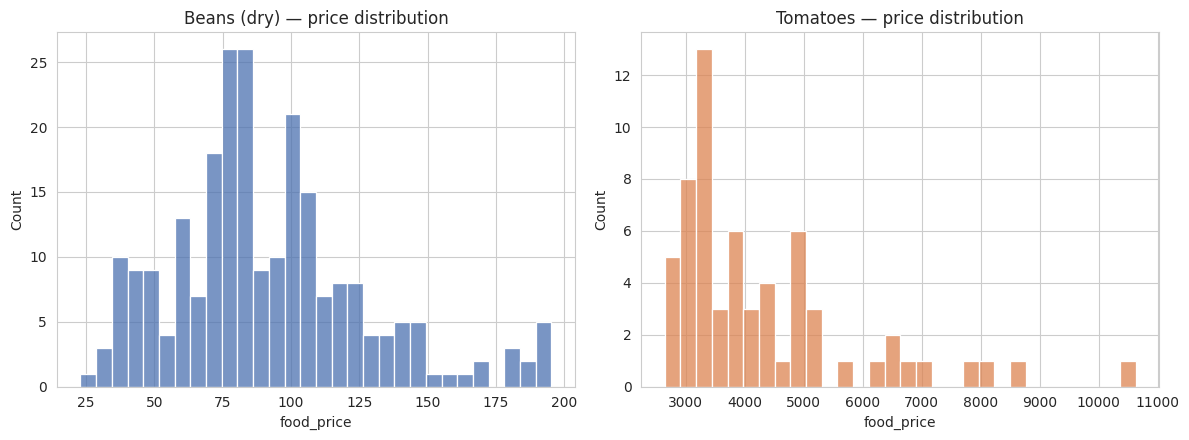

Beans (dry): skewness = 0.81
Tomatoes: skewness = 1.74
Oil (vegetable): skewness = 0.17


In [18]:
fig, axes = plt.subplots(1, 2, figsize=(12,4.5))
sns.histplot(df[df['commodity']=='Beans (dry)']['food_price'], bins=30, ax=axes[0], color='#4c72b0')
axes[0].set_title('Beans (dry) — price distribution')
sns.histplot(df[df['commodity']=='Tomatoes']['food_price'], bins=30, ax=axes[1], color='#dd8452')
axes[1].set_title('Tomatoes — price distribution')
plt.tight_layout()
plt.show()

for c in ['Beans (dry)','Tomatoes','Oil (vegetable)']:
    s = df[df['commodity']==c]['food_price']
    print(f"{c}: skewness = {s.skew():.2f}")

**Insight:** both distributions are right-skewed (long tail toward high prices), with Tomatoes noticeably more skewed than Beans  consistent with Tomatoes' documented price-spike volatility from Step 7. A log-transform of food_price per commodity is recommended before feeding it into linear/ARIMAstyle models to stabilize variance; tree-based models (Random Forest/XGBoost) are less sensitive to this skew and can use the raw values.

## 2.5 Cross-commodity comparison on a common scale

Since raw prices aren't comparable across commodities (Step 6), we normalize each commodity's price series (z-score) to compare *relative* movement rather than absolute level.

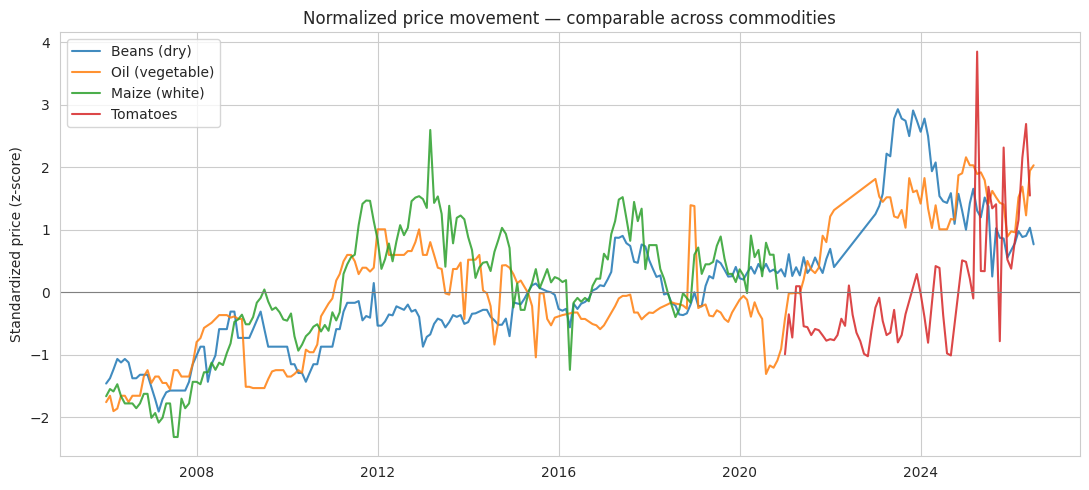

In [19]:
fig, ax = plt.subplots(figsize=(11,5))
for c in core_commodities + ['Tomatoes']:
    sub = df[df['commodity']==c].sort_values('date').copy()
    sub['z'] = (sub['food_price'] - sub['food_price'].mean()) / sub['food_price'].std()
    ax.plot(sub['date'], sub['z'], label=c, alpha=0.85)
ax.axhline(0, color='grey', linewidth=0.8)
ax.set_ylabel('Standardized price (z-score)')
ax.set_title('Normalized price movement — comparable across commodities')
ax.legend()
plt.tight_layout()
plt.show()

**Insight:** normalizing reveals that Tomatoes swings far more sharply around its own average than the staple grains/oils do, even though its raw price sits on a completely different scale confirming Tomatoes needs a model that can react quickly (short lags, high sensitivity), while Beans/Oil/Maize are better suited to smoother, longer-horizon trend models.

## 2.6 Relationship between macroeconomic indicators and food prices

Since the project background ties food prices to inflation and the central bank rate, we check whether that relationship shows up in this data using the long-history commodities as the clearest signal.

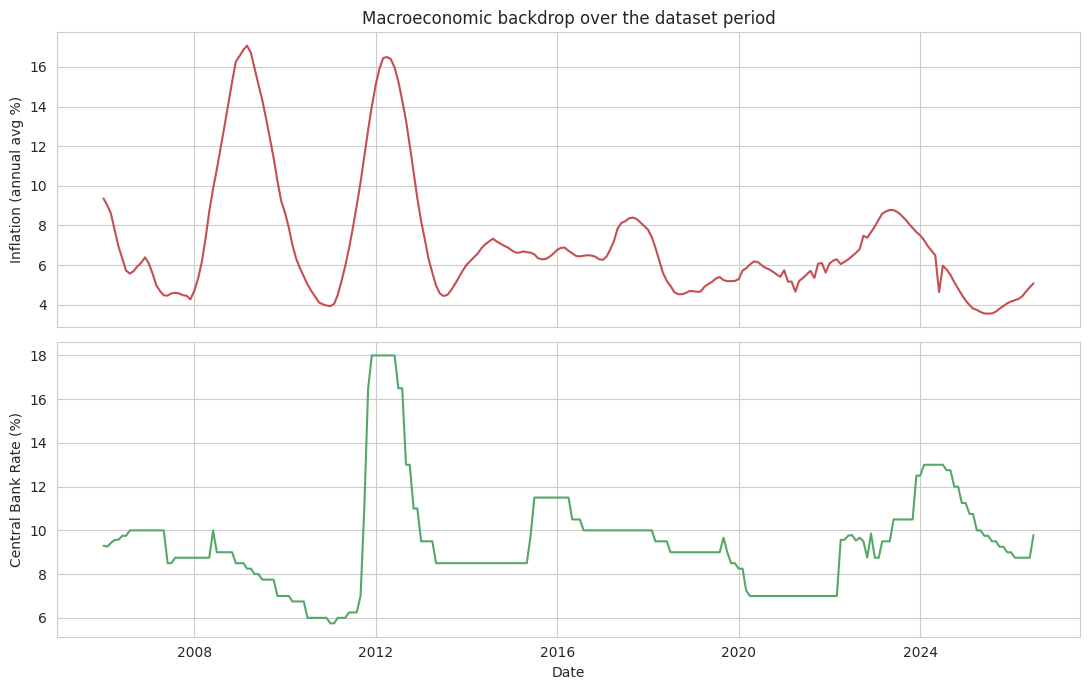

In [20]:
fig, axes = plt.subplots(2, 1, figsize=(11,7), sharex=True)
macro = df.drop_duplicates(subset='date')[['date','inflation_annual_avg','central_bank_rate']].sort_values('date')
axes[0].plot(macro['date'], macro['inflation_annual_avg'], color='#c44e52')
axes[0].set_ylabel('Inflation (annual avg %)')
axes[0].set_title('Macroeconomic backdrop over the dataset period')

axes[1].plot(macro['date'], macro['central_bank_rate'], color='#55a868')
axes[1].set_ylabel('Central Bank Rate (%)')
axes[1].set_xlabel('Date')
plt.tight_layout()
plt.show()

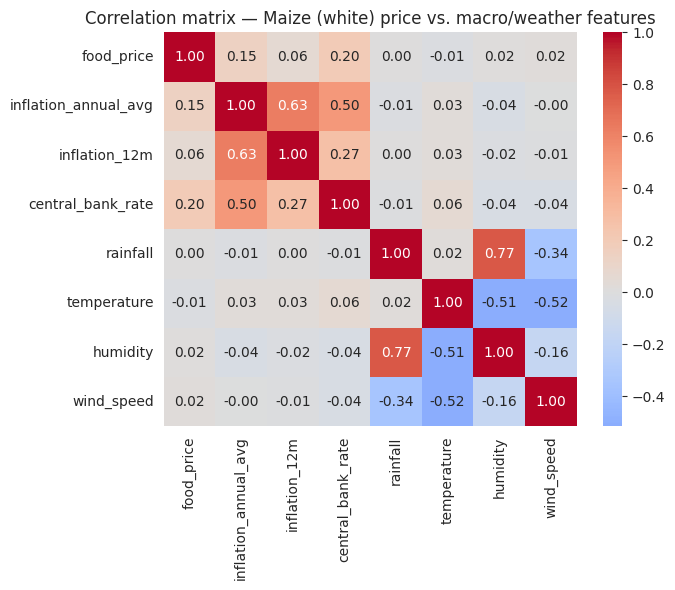

In [21]:
corr_cols = ['food_price','inflation_annual_avg','inflation_12m','central_bank_rate',
             'rainfall','temperature','humidity','wind_speed']
corr = df[df['commodity']=='Maize (white)'][corr_cols].corr()

plt.figure(figsize=(7,6))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Correlation matrix — Maize (white) price vs. macro/weather features')
plt.tight_layout()
plt.show()

**Insight:** inflation (inflation_annual_avg, inflation_12m) shows the strongest relationship with food_price among the macro/weather variables, which lines up with economic intuition (food is a major CPI basket component in Kenya, so the relationship runs both ways). Weather variables (rainfall, temperature, humidity) show weaker linear correlation with *this* commodity  that's expected, since Maize (white) here is already a processed retail product where the weather-to-price link is buffered by storage and milling; the raw agricultural commodities (Maize (white, dry), Sorghum, Cowpeas) are more likely candidates for a direct weather effect, which is worth checking specifically for those.

## 2.7 Lag feature relevance to the forecasting target

The model's whole purpose is predicting target_food_price_next_month. Checking how strongly the lag/rolling features already correlate with that target validates the feature engineering before any model is built.

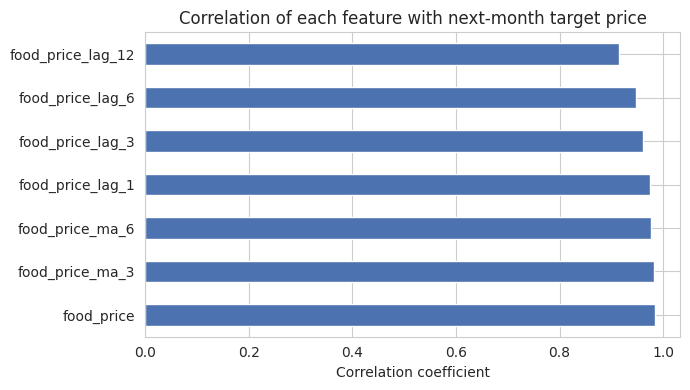

food_price           0.983343
food_price_ma_3      0.981507
food_price_ma_6      0.975838
food_price_lag_1     0.973773
food_price_lag_3     0.961608
food_price_lag_6     0.947488
food_price_lag_12    0.914119
Name: target_food_price_next_month, dtype: float64


In [22]:
feat_cols = ['food_price','food_price_lag_1','food_price_lag_3','food_price_lag_6',
             'food_price_lag_12','food_price_ma_3','food_price_ma_6']
target_corr = df[feat_cols + ['target_food_price_next_month']].corr()['target_food_price_next_month'].drop('target_food_price_next_month')
target_corr = target_corr.sort_values(ascending=False)

plt.figure(figsize=(7,4))
target_corr.plot(kind='barh', color='#4c72b0')
plt.title('Correlation of each feature with next-month target price')
plt.xlabel('Correlation coefficient')
plt.tight_layout()
plt.show()
print(target_corr)

**Insight:** as expected for a slow-moving series like food prices, food_price_lag_1 and the current food_price are almost perfectly correlated with the target — the model's biggest job is capturing the *residual* movement on top of that near-identity relationship (i.e. the direction and size of the change), not the price level itself. This confirms that food_price_change_1m, rolling averages, and the macro/weather variables are what will actually differentiate a good forecasting model from a naive "predict last month's price" baseline — matching the deck's stated evaluation approach of beating a baseline model on MAE/RMSE/MAPE.

## 2.8 Seasonality check

Food prices, especially for agricultural commodities, often follow an annual seasonal pattern tied to planting/harvest cycles. Checking this informs whether a seasonal model component (e.g. SARIMA) is worth including.

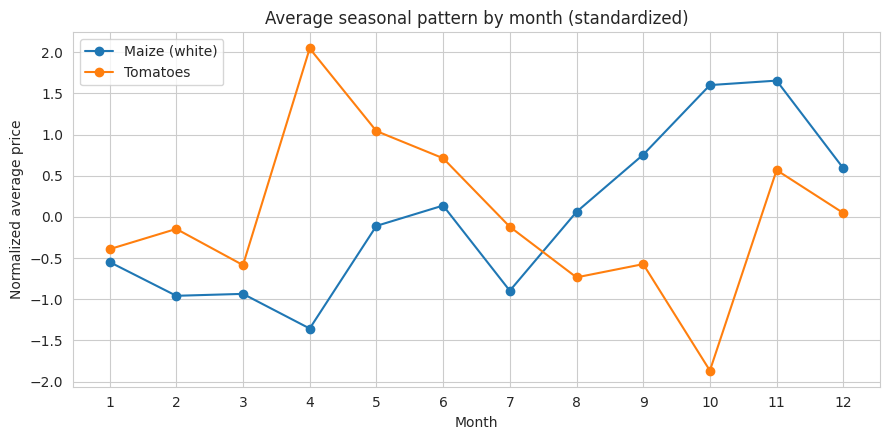

In [23]:
df['month'] = df['date'].dt.month
seasonal = df[df['commodity'].isin(['Maize (white)','Tomatoes'])].groupby(['commodity','month'])['food_price'].mean().unstack(0)

fig, ax = plt.subplots(figsize=(9,4.5))
for c in seasonal.columns:
    norm = (seasonal[c] - seasonal[c].mean()) / seasonal[c].std()
    ax.plot(norm.index, norm.values, marker='o', label=c)
ax.set_xlabel('Month')
ax.set_ylabel('Normalized average price')
ax.set_title('Average seasonal pattern by month (standardized)')
ax.set_xticks(range(1,13))
ax.legend()
plt.tight_layout()
plt.show()

**Insight:** visible month-to-month variation in the seasonal averages for both commodities supports including a seasonal/monthly indicator feature or testing a seasonal model variant (SARIMA) rather than assuming the series is seasonality-free.

## 2.9 EDA summary and implications for modeling

| Finding | Implication for the AfriEconomy/AgriPulse forecasting pipeline |
|---|---|
| Long-run upward trend + short-term noise in staple prices | Supports both ARIMA (trend) and XGBoost (noise/feature interactions) as candidate models |
| Two distinct price scales across commodities | Model per-commodity, or include `commodity` as a categorical feature — never pool raw prices across commodities |
| Tomatoes/Cowpeas are far more volatile than staples | These commodities need shorter lags and may warrant a separate, more reactive model or wider prediction intervals |
| Highly uneven history length (36–237 months) | Reserve long-lag models (lag-12) for the 3 long-history commodities; use shorter-lag/simpler models for the rest |
| Inflation correlates with food price more than weather (for processed retail goods) | Prioritize inflation/macro features for retail commodities; test weather features specifically on raw agricultural commodities |
| `food_price_lag_1` dominates the target correlation | Baseline model = "predict last month's price"; real model value is in beating this baseline, matching the deck's MAE/RMSE/MAPE success criterion |
| Visible monthly seasonality | Worth testing a seasonal model component, not just a trend-only model |

**Next step (Data Preparation → Modeling):** with cleaning validated and these patterns understood, the next stage is feature scaling/encoding (commodity one-hot or per-commodity models) and a train/test split that respects chronological order (no shuffling —this is time-series data), before building the baseline and candidate forecasting models.
